In [1]:
from crewai import Agent, Task, Crew
import os
from dotenv import load_dotenv

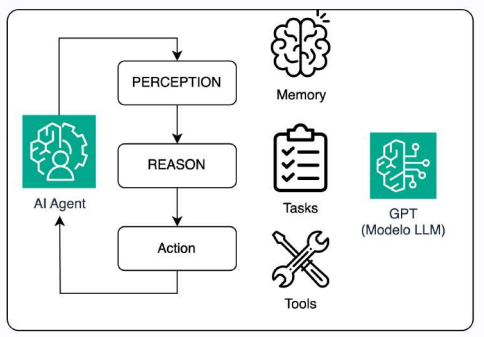

In [2]:
load_dotenv()

True

## Grupo de agentes para escrever artigos

1- Planner - Planejador do artigo

2 - Writer - Escritor do artgio

3 - Editor - Editor do artigo

In [3]:
planner = Agent(
    role="Content Planner",
    goal="Plan engaging content about the {topic}",
    backstory="""You're working on planning a blog post article about
    the topic {topic}.
    You collect information that helps the audience learn something
    and make informed decisions.
    Your work is the basis for the Content Writer to write the article on this topic.
    """,
    allow_delegation=False, # o agente nao pode delegar a sua tarefa
    verbose=True
)

In [4]:
writer = Agent(
    role="Content Writer",
    goal="Write insightfull and factually accurate opinion about the topic {topic}",
    backstory="""You're working on writing an opinion about the topic: {topic}.
    You base your opinion on the work of the Content Planner, who provides an outline and relevant context
    about the topic. you follow the main objectives and direction of the outline, as provided by the Content Planner.
    You also provide objective and impartial insights and back them with information provided by the Content Planner.
    """,
    allow_delegation=False, # o agente nao pode delegar a sua tarefa
    verbose=True
)

In [5]:
editor = Agent(
    role="Editor",
    goal="Edit a given blog post article to align with the writing style of the organization.",
    backstory=""" You're a editor that receives a blog post from the Content Writer.
    Your goal is to review the blog post to ensure that it follows journalistic best practices.
""",
    allow_delegation=False, # o agente nao pode delegar a sua tarefa
    verbose=True
)

In [6]:
plan = Task(
    description=(
        "1. Prioritaze the last trends, key players, and noteworthy news on {topic}"
        "2. Identify the target audience, considering their interests and pain points."
        "3. Develop a detaild content outline including an introduction, key points, and call to action."
        "4. Include SEO keyword and relevant data or sources."
    ),
    expected_output="A comprehensive content plan document with an outline, audience analysis, SEO keywords and resources.",
    agent=planner
)

In [7]:
write = Task(
    description=(
        "1. Use the content plan to craft a compelling blog post on topic: {topic}"
        "2. Incorporate the SEO keywords naturally."
        "3. Sections/Subtitles are properly named in engaging manner."
        "4. Ensure the post is scructured with an engaging introduction, insightfull body, and summarization conclusion."
    ),
    expected_output="A well-written blog post in markdown format, ready for publication, each section should have 2 or 3 paragraphs.",
    agent=planner
)

In [8]:
edit = Task(
    description=("Proofread the given post for grammatical erros and aligment with the brand's voice"),
    expected_output="A well-written blog post in markdown format, ready for publication, each section should have 2 or 3 paragraphs.",
    agent=editor
)

In [10]:
crew = Crew(
    agents=[planner, writer, editor],
    tasks=[plan,write,edit],
    verbose=True
)

In [11]:
result = crew.kickoff(inputs={"topic": "Artificial Inteligence"})

╭──────────────────────────────────────────── ✨ Update Available ✨ ─────────────────────────────────────────────╮
│                                                                                                                 │
│  A new version of CrewAI is available!                                                                          │
│                                                                                                                 │
│  Current version: 1.11.0                                                                                        │
│  Latest version:  1.11.1                                                                                        │
│                                                                                                                 │
│  To update, run: uv sync --upgrade-package crewai                                                               │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 712106b7-be10-4fc4-9694-8d8ee916505d                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: 1. Prioritaze the last trends, key players, and noteworthy news on Artificial Inteligence2. Identify     │
│  the target audience, considering their interests and pain points.3. Develop a detaild content outline          │
│  including an introduction, key points, and call to action.4. Include SEO keyword and relevant data or          │
│  sources.                                                                                                       │
│  ID: f8048353-2896-4ff2-92f3-888aea34a6cd                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Content Planner                                                                                         │
│                                                                                                                 │
│  Task: 1. Prioritaze the last trends, key players, and noteworthy news on Artificial Inteligence2. Identify     │
│  the target audience, considering their interests and pain points.3. Develop a detaild content outline          │
│  including an introduction, key points, and call to action.4. Include SEO keyword and relevant data or          │
│  sources.                                                                                                       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Content Planner                                                                                         │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Content Plan Document                                                                                          │
│                                                                                                                 │
│  Topic: Exploring Artificial Intelligence: Trends, Key Players, and the Future                                  │
│                                                                                                                 │
│  Outline:                                                                                                       │
│  I. Introduction                                                                                                │
│      A. Definition of Artificial Intelligence (AI)                                                              │
│      B. Importance of AI in today's technological landscape                                                     │
│  II. Last Trends in Artificial Intelligence                                                                     │
│      A. Chatbots and Virtual Assistants                                                                         │
│      B. AI in Healthcare                                                                                        │
│      C. Autonomous Vehicles                                                                                     │
│  III. Key Players in the AI Industry                                                                            │
│      A. Google                                                                                                  │
│      B. Amazon                                                                                                  │
│      C. Microsoft                                                                                               │
│  IV. Noteworthy News in Artificial Intelligence                                                                 │
│      A. Breakthroughs in Deep Learning                                                                          │
│      B. AI Ethics and Bias Concerns                                                                             │
│      C. AI in the Global Economy                                                                                │
│  V. Audience Analysis                                                                                           │
│      A. Target Audience: Tech enthusiasts, entrepreneurs, businesses, and professionals interested in AI        │
│      B. Interests: Emerging AI technologies, applications of AI in various industries                           │
│      C. Pain Points: Understanding complex AI concepts, staying updated on the latest trends                    │
│  VI. SEO Keywords: Artificial Intelligence, AI trends, Key players in AI, AI news, Future of AI                 │
│  VII. Resources                                                                                                 │
│      A. Sources: Forbes, TechCrunch, MIT Technology Review                                                      │
│      B. Data: Reports from Gartner, Deloitte, McKinsey on AI trends                                             │
│                                                                                                                 │
│  Call to Action: Stay informed about the latest develop

...

╭─────────────────────────────────────────────── Execution Traces ────────────────────────────────────────────────╮
│                                                                                                                 │
│  🔍 Detailed execution traces are available!                                                                    │
│                                                                                                                 │
│  View insights including:                                                                                       │
│    • Agent decision-making process                                                                              │
│    • Task execution flow and timing                                                                             │
│    • Tool usage details                                                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Would you like to view your execution traces? [y/N] (20s timeout): 



╭────────────────────────── Tracing Preference Saved ──────────────────────────╮
│                                                                              │
│  Info: Tracing has been disabled.                                            │
│                                                                              │
│  Your preference has been saved. Future Crew/Flow executions will not        │
│  collect traces.                                                             │
│                                                                              │
│  To enable tracing later, do any one of these:                               │
│  • Set tracing=True in your Crew/Flow code                                   │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file               │
│  • Run: crewai traces enable                                                 │
│                                                                              │
╰─────────────────────────

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 712106b7-be10-4fc4-9694-8d8ee916505d                                                                       │
│  Final Output: # Exploring Artificial Intelligence: Trends, Key Players, and the Future                         │
│                                                                                                                 │
│  In the constantly evolving world of technology, Artificial Intelligence (AI) has emerged as a prominent and    │
│  transformative force. AI encompasses the simulation of human intelligence processes by machines, encompassing  │
│  learning, reasoning, and self-correction. Its significance is paramount in reshaping industries,               │
│  revolutionizing operations, communication, and innovation processes.                                           │
│                                                                                                                 │
│  ## Embracing Current Trends in AI                                                                              │
│                                                                                                                 │
│  Among the prevailing trends in AI, the widespread integration of chatbots and virtual assistants stands out.   │
│  These AI-driven tools have redefined customer service by providing personalized and swift responses to user    │
│  queries. Within the healthcare sector, AI has demonstrated significant advancements, enhancing diagnostic      │
│  precision, treatment strategies, and overall patient care quality. From robotic-assisted surgeries to          │
│  personalized treatments, AI is fundamentally altering the healthcare landscape. Moreover, the utilization of   │
│  AI technology in autonomous vehicles is revolutionizing transportation, promising safer and more efficient     │
│  mobility solutions.                                                                                            │
│                                                                                                                 │
│  ## Key Industry Players Shaping AI's Trajectory                                                                │
│                                                                                                                 │
│  Within the AI landscape, industry frontrunners like Google, Amazon, and Microsoft play pivotal roles in        │
│  steering innovation forward. These tech behemoths heavily invest in AI research and development, propelling    │
│  advancements in natural language processing, computer vision, and machine learning. Their endeavors not only   │
│  refine consumer experiences but also dictate the course of AI applications across diverse domains.             │
│                                                                                                                 │
│  ## Staying Informed on Vital AI Developments                                                                   │
│                                                                                                                 │
│  Recent AI progress has seen significant breakthroughs in deep learning, a branch of machine learning that      │
│  focuses on emulating human learning processes. Nevertheless, the escalating integration of AI has spurred      │
│  discussions concerning ethics and biases inherent in AI decision-making frameworks. Concerns regarding         │
│  transparency, accountability, and equity in AI algori

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [13]:
from IPython.display import Markdown

Markdown(str(result))

# Exploring Artificial Intelligence: Trends, Key Players, and the Future

In the constantly evolving world of technology, Artificial Intelligence (AI) has emerged as a prominent and transformative force. AI encompasses the simulation of human intelligence processes by machines, encompassing learning, reasoning, and self-correction. Its significance is paramount in reshaping industries, revolutionizing operations, communication, and innovation processes.

## Embracing Current Trends in AI

Among the prevailing trends in AI, the widespread integration of chatbots and virtual assistants stands out. These AI-driven tools have redefined customer service by providing personalized and swift responses to user queries. Within the healthcare sector, AI has demonstrated significant advancements, enhancing diagnostic precision, treatment strategies, and overall patient care quality. From robotic-assisted surgeries to personalized treatments, AI is fundamentally altering the healthcare landscape. Moreover, the utilization of AI technology in autonomous vehicles is revolutionizing transportation, promising safer and more efficient mobility solutions.

## Key Industry Players Shaping AI's Trajectory

Within the AI landscape, industry frontrunners like Google, Amazon, and Microsoft play pivotal roles in steering innovation forward. These tech behemoths heavily invest in AI research and development, propelling advancements in natural language processing, computer vision, and machine learning. Their endeavors not only refine consumer experiences but also dictate the course of AI applications across diverse domains.

## Staying Informed on Vital AI Developments

Recent AI progress has seen significant breakthroughs in deep learning, a branch of machine learning that focuses on emulating human learning processes. Nevertheless, the escalating integration of AI has spurred discussions concerning ethics and biases inherent in AI decision-making frameworks. Concerns regarding transparency, accountability, and equity in AI algorithms have prompted debates on the ethical dimensions of AI technologies. Additionally, AI's integration into the global economy is reshaping industries, propelling productivity enhancements, and sculpting novel business paradigms.

As we navigate the realm of Artificial Intelligence, staying abreast of current trends, significant players, and milestone developments shaping AI's future is imperative. Whether you're a tech enthusiast, entrepreneur, business professional, or simply intrigued by AI's potential, maintaining a pulse on the ever-evolving AI landscape is critical. Subscribe to our newsletter to receive regular updates and insights on AI technological advancements and embark on this thrilling journey towards a smarter, AI-driven tomorrow.